In [4]:
# helper functions (copied from aux_fcn to avoid dependency issue)
import matplotlib.pyplot as plt
import numpy as np

def get_performance(pred_events, true_events, threshold=0, exclude_matched_trues=False, verbose=True):

    '''
    [precision, recall, F1, TP, FN, IOU] = get_performance(pred_events, true_events)
    Computes all these measures given a cell array with boundaries of pred_events

    Inputs:
    -------
        pred_events		 Nx2 matrix with start and end of pred events (seconds)
        true_events		 Mx2 matrix with start and end of true events (seconds)
        threshold		   Threshold to IoU. By default is 0
        exclude_matched_trues False by defaut (one true can match many predictions)

    Output:
    -------
        precision		   Metric indicating the percentage of correct 
                            predictions out of total predictions
        recall			  Metric indicating the percentage of true events 
                            predicted correctly
        F1				  Metric with a measure that combines precision and recall.
        TP				  Nx1 matrix indicating which pred event detected a true event, and
                            a true positive (True) or was false negative (False)
        FN				  Mx1 matrix indicating which true event has been detected (False)
                            or not (True)
        IOU				 NxM array with intersections over unions

    A Navas-Olive, LCN 2020
    '''

    # Check similarity of pred and true events by computing if intersection over union > 0
    # Compute IOU
    [IOU, IOU_pred, IOU_true] = intersection_over_union(pred_events, true_events)
    # IOU_pred-> IOU de cada evento predecido
    # IOU_true-> IOU de la GT


 # Excluye los true coincidentes
    if exclude_matched_trues:
        # Take maximal IOUs, and make the rest be zero
        pred_with_maxIOU = np.argmax(IOU, axis=0)
        IOU_pred_one_true_match = np.zeros_like(IOU)
        for itrue, ipred in enumerate(pred_with_maxIOU):
            IOU_pred_one_true_match[ipred, itrue] = IOU[ipred, itrue]
        # True positive: Predicted event that has a IoU with any true > 0
        TP = (IOU_pred_one_true_match.sum(axis=1) > threshold)
        # False negative: Predicted event that has not a IoU with any true
        FN = (IOU_true <= threshold)

    else:
        # True positive: Predicted event that has a IoU with any true > 0
        # 
        TP = (IOU_pred>threshold) 
        # False negative: Predicted event that has not a IoU with any true
        FN = (IOU_true<=threshold)  
    
    # Precision and recall
    precision = np.mean(TP)      # Media de verdaderos positivos: 1 si todas las predicciones son aciertos
    recall = 1. - np.mean(FN)    # 1-media de falsos negativos: 1 si toda la GT está presente en los aciertos
    F1 = 2. * (precision * recall) / (precision + recall)  
    if (precision + recall) == 0:
        F1 = 0.
    else:
        F1 = 2. * (precision * recall) / (precision + recall)

    if verbose:
        print('precision =', precision)
        print('recall =', recall)
        print('F1 =', F1)
    
    # Variable outputs
    return precision, recall, F1, TP, FN, IOU

def intersection_over_union(x, y):
    '''
    IOU = intersection_over_union(x, y) computes the percentage of 
    intersection over their union between every two pair of intervals 
    x and y.
    
    Inputs:
    -------
      x	 Nx2 array with beginnings and ends of 1D events
      y	 Mx2 array with beginnings and ends of 1D events
    
    Output:
    -------
      IOU   NxM array with intersections over unions
      IOUx  (optional) Nx1 array with indexes of y events with maximal IOU 
            It's zero if IOU=0 for all y events
      IOUy  (optional) Mx1 array with indexes of x events with maximal IOU 
            It's zero if IOU=0 for all x events
    
    A Navas-Olive, LCN 2020
    '''

    if (len(x)>0) and (len(y)>0):

        # Initialize
        Intersection = np.zeros((x.shape[0],  y.shape[0]),dtype=np.float32)
        Union = np.ones((x.shape[0],  y.shape[0]),dtype=np.float32)
        # Go through every y (beginning-end) pair
        for iy in range(y.shape[0]):
            # Intersection duration: difference between minimum end and maximum ini
            Intersection[:, iy] = np.maximum( np.minimum(x[:, 1], y[iy, 1]) - np.maximum(x[:, 0], y[iy, 0]), 0)
            # Union duration: sum of durations of both events minus its intersection
            Union[:, iy, None] = np.diff(x, axis=1) + np.diff(y[iy, :]) - Intersection[:, iy, None]

        # Compute intersection over union
        IOU = Intersection / Union

        # Compute which events from y have maximal IOU with x
        IOUx = np.max(IOU, axis=1, keepdims=True)

        # Compute which events from x have maximal IOU with y
        IOUy = np.max(IOU, axis=0, keepdims=True)

        # Optional outputs
        return IOU, IOUx, IOUy
        
    elif len(x)==0:
        
        print('x is empty. Cant perform IoU')
        return np.array([]), np.array([]), np.zeros((y.shape[0], 1))
        
    elif len(y)==0:
        
        print('y is empty. Cant perform IoU')
        return np.array([]), np.zeros((1, x.shape[0])), np.array([])
    
def plot_all_events(t_events, lfp, sf, win=0.100, title='', savefig=''):
    '''
    plot_all_events(t_events, lfp, sf, win=0.100, title='', savefig='')
    
    Mandatory inputs:
    -----------------
        events (numpy array):
            Array of size (#events, 1) with all times of events
        lfp (numpy array):
            formated lfp with all channels
        sf (int): 
            sampling frequency of the 'lfp' variable

    Optional inputs:
    ----------------
        win (float): 
            window size at each side of the center of the ripple
        title (string):
            if provided, displays this title
        savefig (string):
            if provided, saves the image in the savefig directory.
            It has to be the full name: e.g. images/session1_events.png
        
    '''
    # Convert to indexes
    id_events = (t_events*sf).astype(int)
    # Make window array
    ids_win = np.arange(-win*sf , win*sf+1).astype(int)

    # Plot curated events
    n_cols = int(np.sqrt(len(t_events)))*1.5
    plt.figure(figsize=(18,12))
    dx, dy = 0, 0
    list_events = []
    for ii,id_event in enumerate(id_events):
        event = lfp[id_event+ids_win,:]
        plt.plot(dx+np.linspace(.05,.95,len(event)), 
                 dy+(event/3-np.arange(lfp.shape[1]))/lfp.shape[1]*0.8, 
                 linewidth=0.7, color=np.random.rand(3))
        dx = dx+1
        if dx >= n_cols:
            dx = 0
            dy = dy-1
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')
    # Title and save
    if len(title) > 0:
        plt.title(title)
    plt.tight_layout()
    if len(savefig) > 0:
        plt.savefig(savefig)
    plt.show()


In [5]:
import load_fcn
import os
import numpy as np


path=os.path.join('Downloaded_data','Dlx1','figshare_14959449')

sf, expName, ref_channels, dead_channels = load_fcn.load_info(path)
channels_map = load_fcn.load_channels_map(path)
dsf = 1250

# Reformat channels into correct values
channels, shanks, ref_channels = load_fcn.reformat_channels(channels_map, ref_channels)
# Read .dat
print('Channel map value: ',channels)
LFP = load_fcn.load_raw_data(path, expName, channels, verbose=True)
print('Sampling frequency: ', sf)
print('Shape of the original data',LFP.shape)
print(channels_map)

import proc_fcn
# The loaded LFP already contains the requested channels, so use its column indices
lfp_channels = np.arange(LFP.shape[1])

# Interpolate missing channels, downsample, and z-score each channel
LFP_norm = proc_fcn.process_LFP(
    LFP,
    sf=sf,
    d_sf=dsf,
    channels=lfp_channels,
)

print("Preprocessed LFP shape:", LFP_norm.shape)
print("Preprocessed LFP dtype:", LFP_norm.dtype)

Channel map value:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Downloaded_data\Dlx1\figshare_14959449/lfp_Dlx1-2021-02-12_12-46-54.dat
fileStart  0
fileStop  490242048
nSamples  245121024
nSamplesPerChannel  30640128
nSamplesPerChunk  10000
size data  30640128
Sampling frequency:  30000
Shape of the original data (30640128, 8)
[[1 1 2]
 [2 1 2]
 [3 1 2]
 [4 1 2]
 [5 1 2]
 [6 1 2]
 [7 1 2]
 [8 1 2]]
Downsampling data from 30000 to 1250 Hz...
Shape of downsampled data: (1276672, 8)
Normalizing data...
Preprocessed LFP shape: (1276672, 8)
Preprocessed LFP dtype: float16


In [6]:
from ripple_detection import Karlsson_ripple_detector,filter_ripple_band
# for the parida lab data, I might need to make fake timestamps and speed
speed = np.zeros(LFP_norm.shape[0])
time = np.arange(LFP_norm.shape[0]) / dsf
sampling_frequency = dsf

filtered_LFPs = filter_ripple_band(LFP_norm, sampling_frequency)
# Detect ripples with custom parameters
ripples = Karlsson_ripple_detector(
    time, filtered_LFPs[:,4:5], speed, sampling_frequency,
    speed_threshold=4.0,
    minimum_duration=0.015,
    zscore_threshold=3.0,
    smoothing_sigma=0.004,
    close_ripple_threshold=0.0
)

# Access detailed statistics
print(f"Detected {len(ripples)} ripple events")
print(f"Mean duration: {ripples['duration'].mean():.3f} seconds")
print(f"Mean z-score: {ripples['mean_zscore'].mean():.2f}")

C:\Users\lilytong\AppData\Local\Temp\ipykernel_25224\2521199733.py:7: UserWarning: The pre-computed ripple filter is optimized for 1500.0 Hz sampling.
Your data: 1250 Hz. Results may be suboptimal.
For best results, use ripple_bandpass_filter(1250) to generate a custom filter.
  filtered_LFPs = filter_ripple_band(LFP_norm, sampling_frequency)


Detected 234 ripple events
Mean duration: 0.108 seconds
Mean z-score: 3.18


# Compare with true set 

In [10]:
import load_fcn
import os
path=os.path.join('Downloaded_data','Dlx1','figshare_14959449')
sf, expName, ref_channels, dead_channels = load_fcn.load_info(path)
# load ripple indices from the figshare dataset
true = load_fcn.load_ripples(r"F:\GitHub\rippl-AI\Downloaded_data\Dlx1\figshare_14959449")/sf
# reformat prediction to match the function input
predicted = ripples.loc[:,["start_time","end_time"]].values
print("True ripples:", type(true), true.shape)
print("Predicted ripples:", type(predicted), predicted.shape)

# make the comparison
percision, recall, F1, TP, FN, IOU = get_performance(predicted, true, threshold=0.0, exclude_matched_trues=False, verbose=True)

True ripples: <class 'numpy.ndarray'> (211, 2)
Predicted ripples: <class 'numpy.ndarray'> (234, 2)
precision = 0.7435897435897436
recall = 0.8483412322274881
F1 = 0.7925190839694656


In [ ]:
id_fn = np.where(FN)[]
id_fn

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([  3,   5,   9,  10,  20,  25,  36,  38,  45,  54,  55,  67,  97,
         99, 102, 123, 131, 139, 151, 155, 162, 165, 168, 172, 180, 181,
        185, 187, 196, 197, 202, 203]))

Number of true positives: 174
Number of false positives: 60


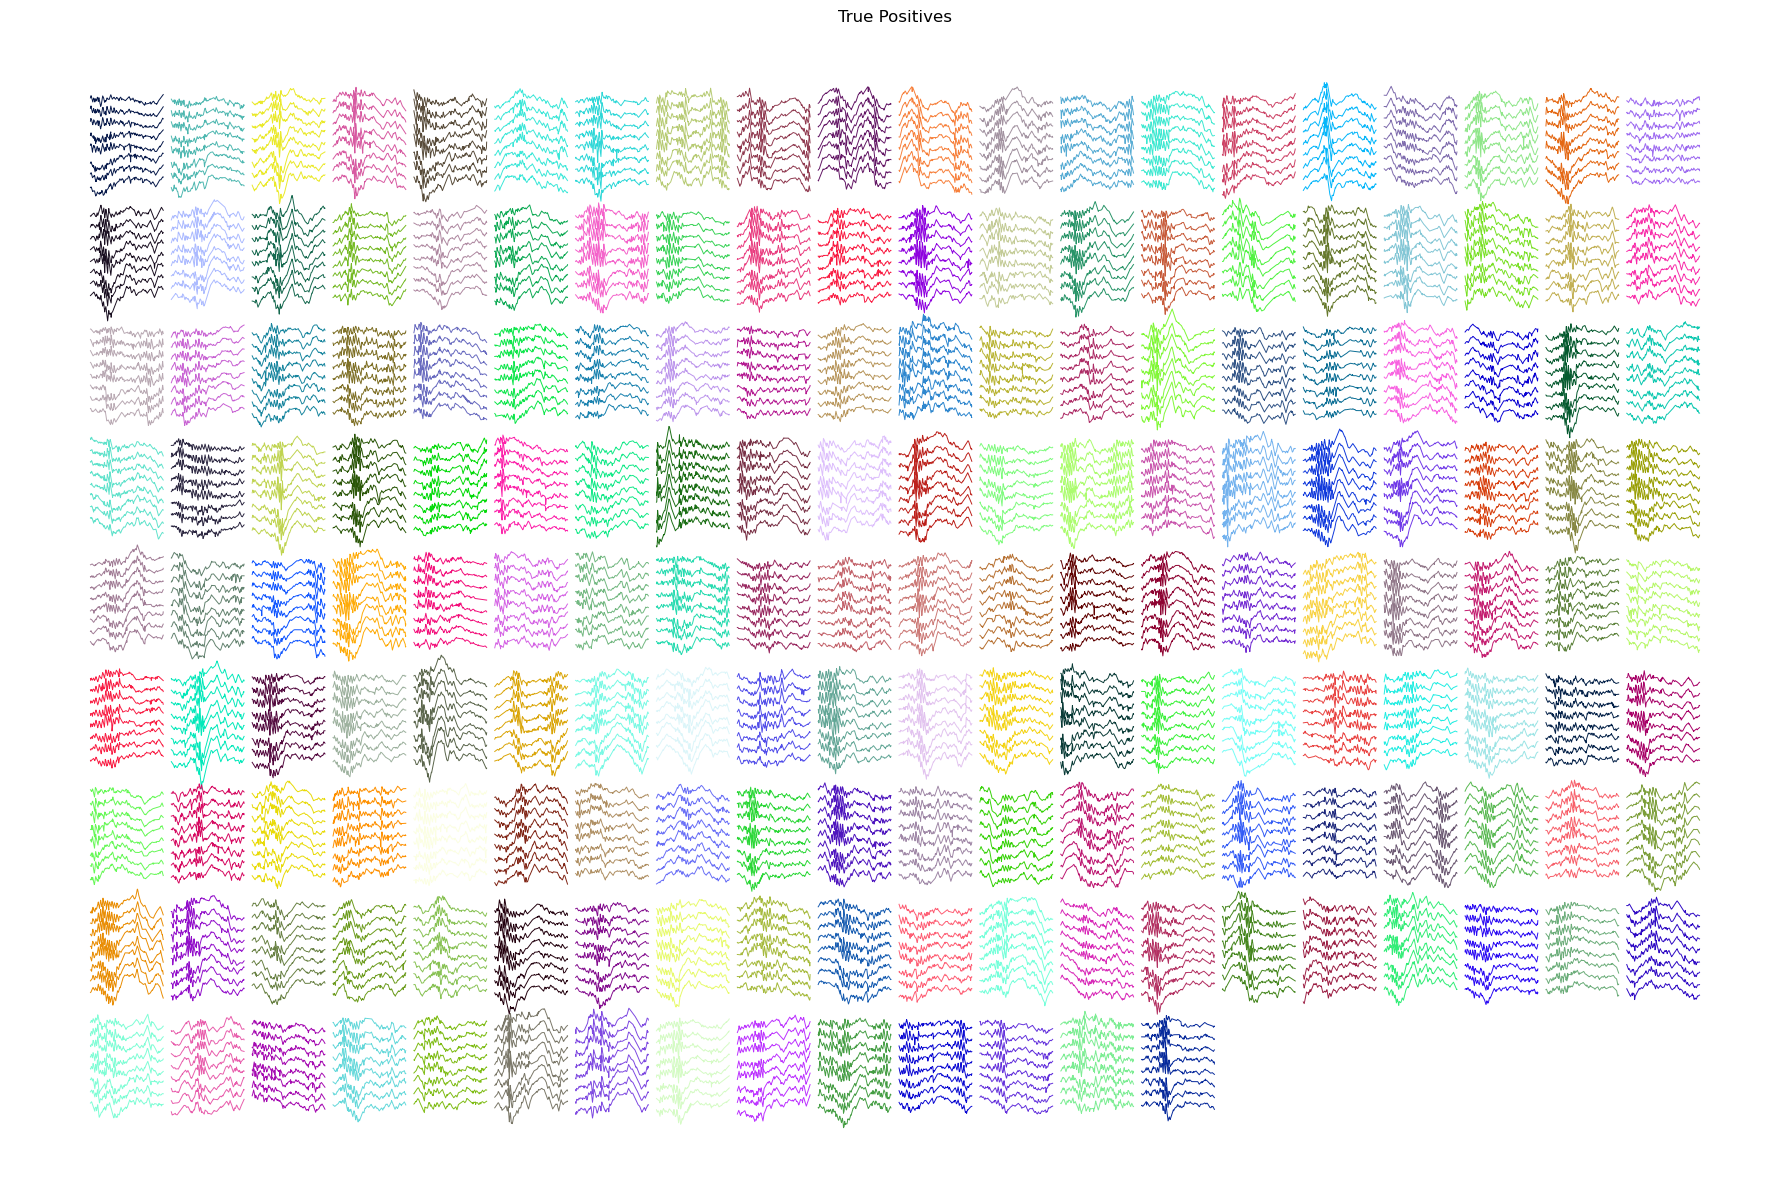

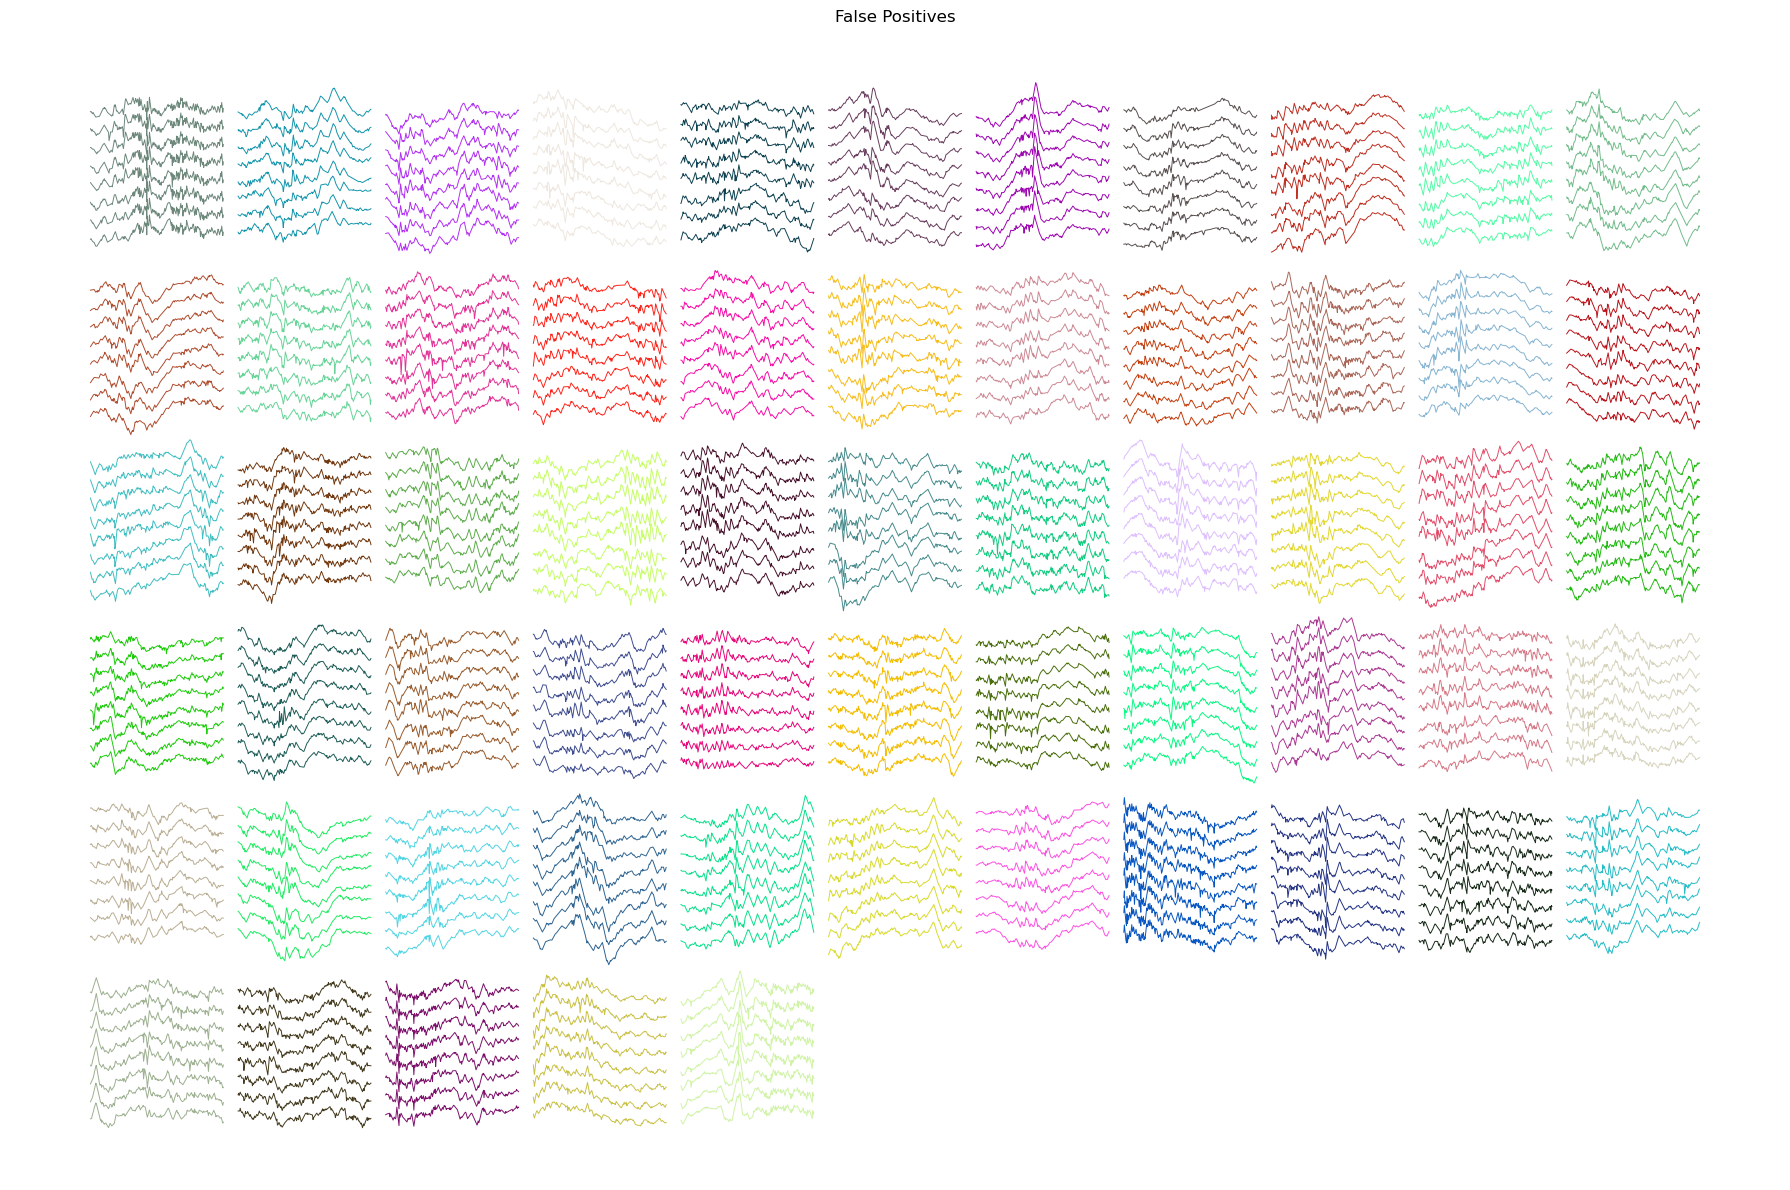

Number of false negatives: 32


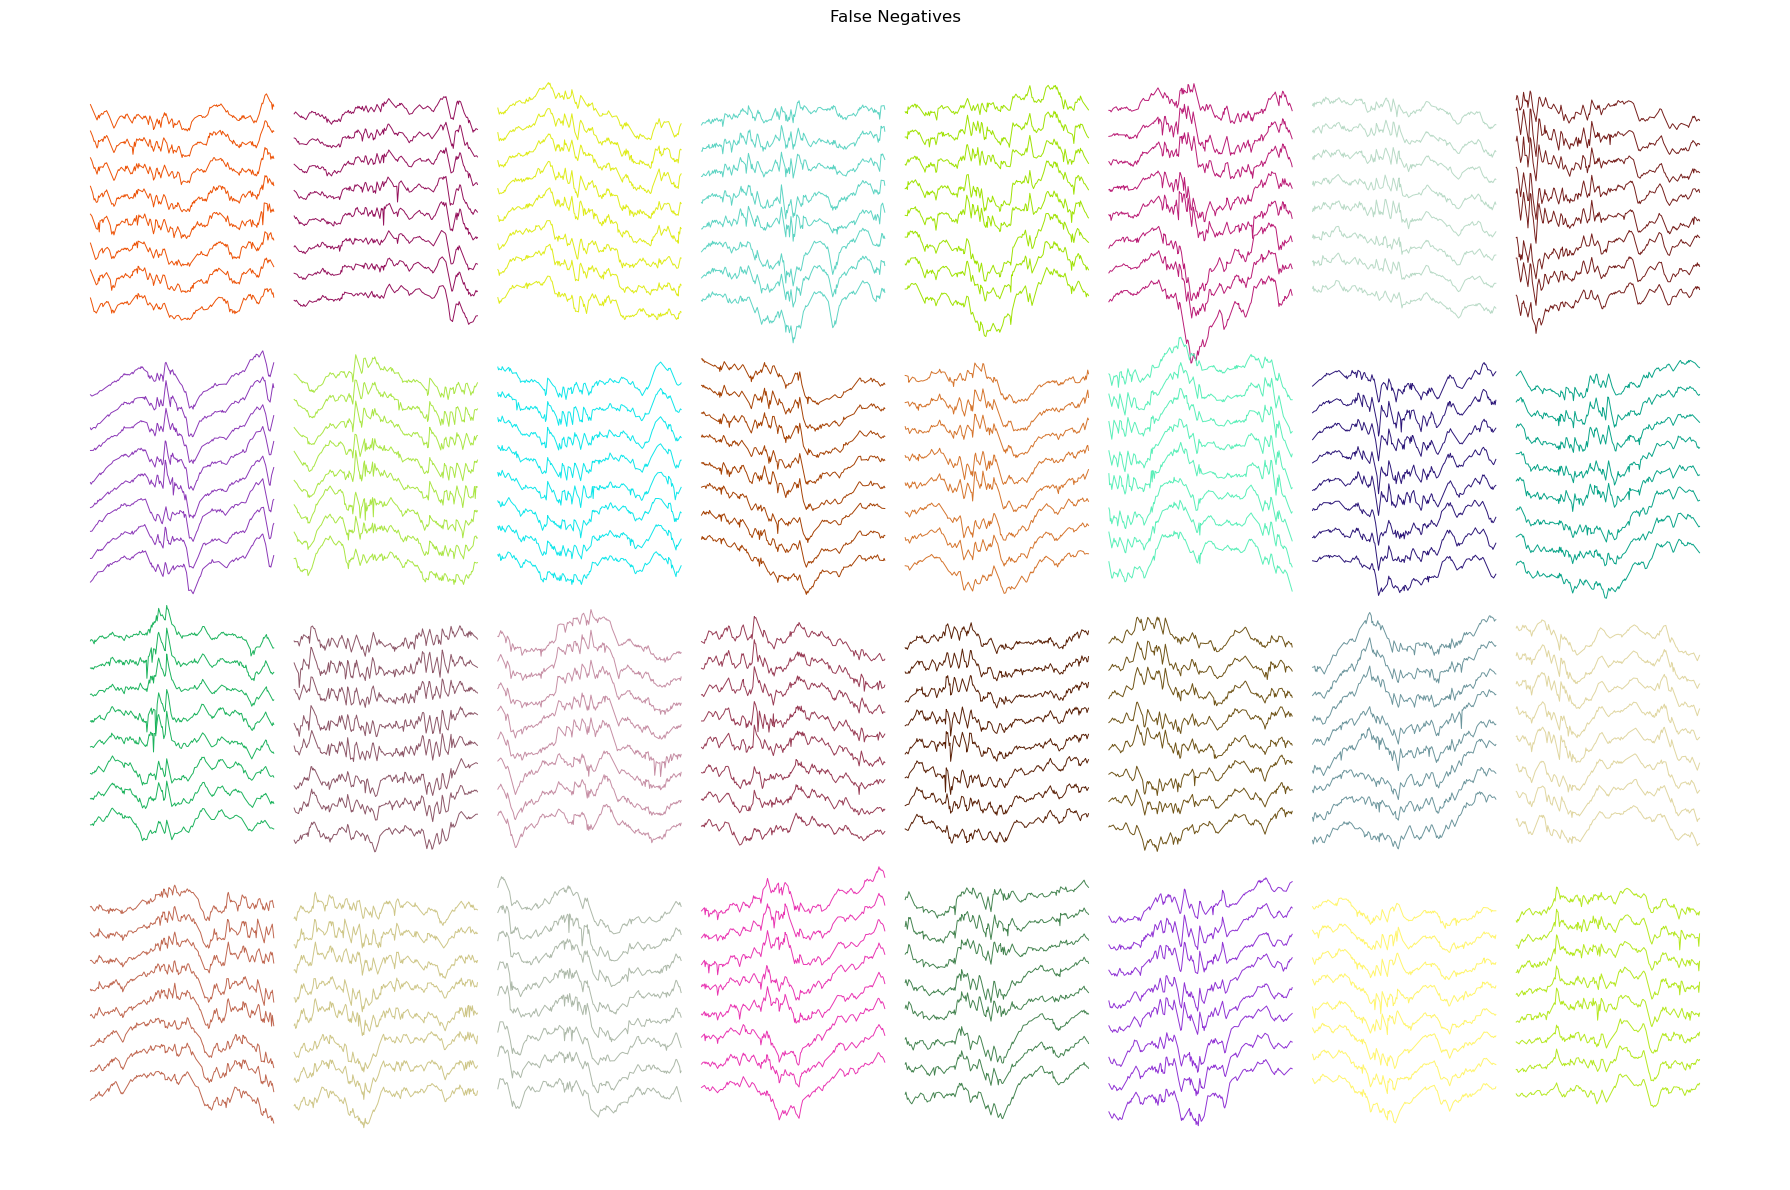

In [ ]:
# visualize examples of True positives and false positives
import numpy as np

mid = predicted[:,1] - predicted[:,0] + predicted[:,0]
id_tp = np.where(TP)[0]
id_fp = np.where(~TP)[0]

print(f"Number of true positives: {len(id_tp)}")
print(f"Number of false positives: {len(id_fp)}")

# Plot true positives
plot_all_events(mid[id_tp], LFP_norm, dsf, title='True Positives')
    
# Plot false positives
plot_all_events(mid[id_fp], LFP_norm, dsf, title='False Positives')
s

# Allen data

In [ ]:
# load data
import numpy as np
lfp_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_754312389_756781561.npy"
time_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_time_754312389_756781561.npy"
speed_path = r"F:\GitHub\rippl-AI\allen_data\lfp_use_speed_754312389_756781561.npy"

LFPs = np.load(lfp_path)  # Load LFP data from .npy file
time = np.load(time_path)  # Load time data from .npy file
speed = np.load(speed_path)

# time = np.arange(0, 10, 0.001)  # 10 seconds at 1000 Hz
# LFPs = np.random.randn(len(time), 4)  # 4 channels of LFP data
# speed = np.abs(np.random.randn(len(time)))  # Animal speed
sampling_frequency = 1250  # Hz

from ripple_detection import Kay_ripple_detector

# Detect ripples
ripple_times = Kay_ripple_detector(
    time, LFPs, speed, sampling_frequency,
    speed_threshold=4.0,        # cm/s
    minimum_duration=0.015,     # seconds
    zscore_threshold=2.0
)

from ripple_detection import Karlsson_ripple_detector,filter_ripple_band

# Detect ripples with custom parameters
ripples = Karlsson_ripple_detector(
    time, LFPs[:,4:5], speed, sampling_frequency,
    speed_threshold=4.0,
    minimum_duration=0.015,
    zscore_threshold=3.0,
    smoothing_sigma=0.004,
    close_ripple_threshold=0.0
)

# Access detailed statistics
print(f"Detected {len(ripples)} ripple events")
print(f"Mean duration: {ripples['duration'].mean():.3f} seconds")
print(f"Mean z-score: {ripples['mean_zscore'].mean():.2f}")
